# Compression Validation Notebook

This notebook is designed to fill **deficiency D004** for the dissertation. It builds a real-data validation package for **RQ3** using the same standardized real-data settings already used elsewhere in the repository, then adds the missing anytime-frontier, non-inferiority, and deployment-policy views.


## D004 Deliverables

The notebook produces the three missing artifacts called out in `documentation/deficiencies.md`:

1. **Full real-data `J`-versus-`k` frontiers** on held-out data across the HAI attack subsets and the standardized ionosphere probe.
2. **Equivalence / non-inferiority summaries** comparing the compressed rule against the upstream rectified sparse baseline.
3. **A prespecified adoption-policy summary** showing how aggressive or conservative compression changes the selected rule size.

The goal is not only to show that compression can work, but to show **when it should be accepted** under an explicit policy instead of an ad hoc visual judgment.


In [51]:
from __future__ import annotations

import json
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

for module_name in [name for name in list(sys.modules) if name == "cutlass" or name.startswith("cutlass.")]:
    del sys.modules[module_name]

cutlass = importlib.import_module("cutlass")
Rectifier = cutlass.Rectifier
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
CutlassLogisticCV = cutlass.CutlassLogisticCV
calculate_youden_j = cutlass.calculate_youden_j

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
if sns is not None:
    sns.set(style="whitegrid")


In [52]:
def _find_repo_root() -> Path:
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


REPO_ROOT = _find_repo_root()
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
RAW_DATA_DIR = NOTEBOOKS_DIR / "raw_data"
PROCESSED_DIR = NOTEBOOKS_DIR / "processed_data"
MANUSCRIPT_FIGURES_DIR = REPO_ROOT / "Figures"
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "compression_validation"

MANUSCRIPT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Run directory:", RUN_DIR)
print("Manuscript figure directory:", MANUSCRIPT_FIGURES_DIR)


Repository root: C:\Users\jason\ODU\dissertation
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation
Manuscript figure directory: C:\Users\jason\ODU\dissertation\Figures


In [53]:
# Strict-policy knobs. Edit these constants to change the dissertation's
# default compression-adoption rule without touching the analysis code
# below.
STRICT_POLICY_LABEL = "2%"
STRICT_POLICY_EPS = 0.02
STRICT_POLICY_K_SELECTION_RULE = "smallest_passing"
STRICT_POLICY_AUC_MARGIN = 0.02
STRICT_POLICY_J_MARGIN = 0.02
STRICT_POLICY_BOOTSTRAP_REPS = 500
STRICT_POLICY_BOOTSTRAP_SEED = 42
STRICT_POLICY_DEPLOYMENT_REQUIREMENT = "both"

REAL_DATA_SPECS = [
    {
        "domain": "HAI attack_p2 (a1)",
        "dataset_family": "HAI",
        "kind": "hai",
        "tag": "a1",
        "fixed_c": 0.012,
        "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65)),
        "duplicate_mode": "within_group",
    },
    {
        "domain": "HAI attack_p1p2 (a2)",
        "dataset_family": "HAI",
        "kind": "hai",
        "tag": "a2",
        "fixed_c": 0.012,
        "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65)),
        "duplicate_mode": "within_group",
    },
    {
        "domain": "HAI attack_p3 (a3)",
        "dataset_family": "HAI",
        "kind": "hai",
        "tag": "a3",
        "fixed_c": 0.012,
        "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65)),
        "duplicate_mode": "within_group",
    },
    {
        "domain": "HAI attack_p1p3 (a4)",
        "dataset_family": "HAI",
        "kind": "hai",
        "tag": "a4",
        "fixed_c": 0.012,
        "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65)),
        "duplicate_mode": "within_group",
    },
    {
        "domain": "Ionosphere radar",
        "dataset_family": "Radar",
        "kind": "ionosphere",
        "fixed_c": 0.1,
        "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.25, 0.75)),
        "duplicate_mode": "none",
    },
]

POLICY_GRID = [0.01, 0.02, 0.05]
OVERWRITE_CACHE = False

if not any(np.isclose(STRICT_POLICY_EPS, eps) for eps in POLICY_GRID):
    raise ValueError("STRICT_POLICY_EPS must also appear in POLICY_GRID.")
if STRICT_POLICY_K_SELECTION_RULE not in {"smallest_passing", "best_passing"}:
    raise ValueError("STRICT_POLICY_K_SELECTION_RULE must be 'smallest_passing' or 'best_passing'.")
if STRICT_POLICY_DEPLOYMENT_REQUIREMENT not in {"both", "auc_only", "j_only", "either"}:
    raise ValueError(
        "STRICT_POLICY_DEPLOYMENT_REQUIREMENT must be one of: "
        "'both', 'auc_only', 'j_only', 'either'."
    )

config_view = pd.DataFrame(
    [
        {
            "Parameter": "Domains",
            "Value": ", ".join(spec["domain"] for spec in REAL_DATA_SPECS),
        },
        {
            "Parameter": "Policy grid",
            "Value": ", ".join(f"{int(100 * eps)}%" for eps in POLICY_GRID),
        },
        {
            "Parameter": "Strict policy",
            "Value": (
                f"{STRICT_POLICY_LABEL}: {STRICT_POLICY_K_SELECTION_RULE}, "
                f"train J(k) >= {(1.0 - STRICT_POLICY_EPS):.0%} of baseline train J"
            ),
        },
        {
            "Parameter": "AUC non-inferiority margin",
            "Value": f"-{STRICT_POLICY_AUC_MARGIN:.2f}",
        },
        {
            "Parameter": "J non-inferiority margin",
            "Value": f"-{STRICT_POLICY_J_MARGIN:.2f}",
        },
        {
            "Parameter": "Deployment requirement",
            "Value": STRICT_POLICY_DEPLOYMENT_REQUIREMENT,
        },
        {
            "Parameter": "Bootstrap reps / seed",
            "Value": f"{STRICT_POLICY_BOOTSTRAP_REPS} / {STRICT_POLICY_BOOTSTRAP_SEED}",
        },
    ]
)
if display is not None:
    display(config_view)
else:
    print(config_view.to_string(index=False))


,Parameter,Value
0,Domains,"HAI attack_p2 (a1), HAI attack_p1p2 (a2), HAI ..."
1,Policy grid,"1%, 2%, 5%"
2,Strict policy,"2%: smallest_passing, train J(k) >= 98% of bas..."
3,AUC non-inferiority margin,-0.02
4,J non-inferiority margin,-0.02
5,Deployment requirement,both
6,Bootstrap reps / seed,500 / 42


## Prespecified Adoption Policy

This notebook uses a deliberately simple and auditable deployment rule:

- Fit the **rectified sparse baseline** on the training split using the same standardized real-data settings used in the earlier cross-domain notebook.
- Construct the anytime frontier by ranking nonzero coefficients by `|w|`, converting them to a common logic-polish magnitude, and optimizing the rule threshold **on training only** for each `k`.
- Select the **smallest** `k` such that `J(k) >= (1 - epsilon) * J_base_train`.
- Use the values listed in `POLICY_GRID` for the policy summary, but treat the `STRICT_POLICY_*` constants in the config cell above as the dissertation's default rule.
- For the strict policy, held-out validation is controlled by:
  - `STRICT_POLICY_AUC_MARGIN`
  - `STRICT_POLICY_J_MARGIN`
  - `STRICT_POLICY_BOOTSTRAP_REPS`
  - `STRICT_POLICY_DEPLOYMENT_REQUIREMENT`

The frontier therefore answers two different questions:

1. **Selection**: how much can training-time complexity be reduced before the rule drops below the declared tolerance?
2. **Validation**: after that selection decision, does the chosen rule remain practically non-inferior on held-out data?

A final detail matters for interpretation: because duplicate columns are consolidated before sparse fitting, the reported `k` counts **distinct fit-space logical conditions**, not repeated alias columns.


In [54]:
def render_markdown(text: str) -> None:
    if Markdown is not None and display is not None:
        display(Markdown(text))
    else:
        print(text)


def sigmoid(score) -> np.ndarray:
    score_arr = np.asarray(score, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(score_arr, -40.0, 40.0)))


def format_numeric(value: float, digits: int = 3) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}"


def best_youden_threshold(prob, y_true) -> tuple[float, float]:
    prob_arr = np.asarray(prob, dtype=float)
    y_arr = np.asarray(y_true).astype(int)
    values = np.unique(np.sort(prob_arr))
    if values.size == 0:
        return 0.5, 0.0
    mids = 0.5 * (values[:-1] + values[1:]) if values.size > 1 else np.asarray([], dtype=float)
    thresholds = np.r_[values[0] - 1e-9, mids, values[-1] + 1e-9]
    best_j = -np.inf
    best_thr = float(thresholds[0])
    for thr in thresholds:
        pred = (prob_arr >= thr).astype(int)
        j = float(calculate_youden_j(y_arr, pred))
        if j > best_j:
            best_j = j
            best_thr = float(thr)
    return best_thr, float(best_j)


def bootstrap_delta_ci(
    y_true,
    baseline_prob,
    baseline_pred,
    rule_prob,
    rule_pred,
    *,
    reps: int,
    seed: int,
) -> tuple[tuple[float, float], tuple[float, float]]:
    y_arr = np.asarray(y_true).astype(int)
    base_prob_arr = np.asarray(baseline_prob, dtype=float)
    base_pred_arr = np.asarray(baseline_pred).astype(int)
    rule_prob_arr = np.asarray(rule_prob, dtype=float)
    rule_pred_arr = np.asarray(rule_pred).astype(int)
    rng = np.random.default_rng(seed)
    auc_deltas = []
    j_deltas = []
    n = len(y_arr)
    for _ in range(int(reps)):
        idx = rng.integers(0, n, n)
        y_boot = y_arr[idx]
        if np.unique(y_boot).size < 2:
            continue
        auc_deltas.append(
            float(roc_auc_score(y_boot, rule_prob_arr[idx]) - roc_auc_score(y_boot, base_prob_arr[idx]))
        )
        j_deltas.append(
            float(calculate_youden_j(y_boot, rule_pred_arr[idx]) - calculate_youden_j(y_boot, base_pred_arr[idx]))
        )
    if not auc_deltas:
        return (float("nan"), float("nan")), (float("nan"), float("nan"))
    auc_ci = tuple(np.quantile(np.asarray(auc_deltas, dtype=float), [0.025, 0.975]).tolist())
    j_ci = tuple(np.quantile(np.asarray(j_deltas, dtype=float), [0.025, 0.975]).tolist())
    return auc_ci, j_ci


def strict_policy_deployment_decision(
    auc_noninferior: bool,
    j_noninferior: bool,
    *,
    requirement: str,
) -> bool:
    if requirement == "both":
        return bool(auc_noninferior and j_noninferior)
    if requirement == "auc_only":
        return bool(auc_noninferior)
    if requirement == "j_only":
        return bool(j_noninferior)
    if requirement == "either":
        return bool(auc_noninferior or j_noninferior)
    raise ValueError(f"Unsupported strict deployment requirement: {requirement}")


In [55]:
def load_real_data_split(spec: dict) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    if spec["kind"] == "hai":
        train_df = pd.read_parquet(PROCESSED_DIR / f"train_{spec['tag']}_sm_hai.parquet")
        test_df = pd.read_parquet(PROCESSED_DIR / f"test_{spec['tag']}_sm_hai.parquet")
        return (
            train_df.drop(columns=["INDC"]),
            train_df["INDC"].astype(int),
            test_df.drop(columns=["INDC"]),
            test_df["INDC"].astype(int),
        )

    if spec["kind"] == "ionosphere":
        iono_raw = pd.read_csv(RAW_DATA_DIR / "ionosphere.data", header=None)
        X = iono_raw.iloc[:, :-1].copy()
        X.columns = [f"F{i:02d}" for i in range(X.shape[1])]
        y = (iono_raw.iloc[:, -1] == "g").astype(int)
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            stratify=y,
            random_state=42,
        )
        return (
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
            X_test.reset_index(drop=True),
            y_test.reset_index(drop=True),
        )

    raise ValueError(f"Unsupported spec kind: {spec['kind']}")


def prepare_rectified_design(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    *,
    rectifier_kw: dict,
    duplicate_mode: str,
) -> tuple[np.ndarray, np.ndarray]:
    rectifier = Rectifier(groups=None, **rectifier_kw)
    X_train_rect = rectifier.fit_transform(X_train, np.asarray(y_train, dtype=int))
    X_test_rect = rectifier.transform(X_test)
    consolidator = DuplicateColumnConsolidator(mode=duplicate_mode, expansion="split_evenly")
    X_train_fit = consolidator.fit_transform(X_train_rect, feature_names=rectifier.feature_names_)
    X_test_fit = consolidator.transform(X_test_rect, feature_names=rectifier.feature_names_)
    return np.asarray(X_train_fit, dtype=float), np.asarray(X_test_fit, dtype=float)


def fit_cutlass_model(
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    *,
    fixed_c: float,
    logic_polish: bool,
):
    # n_jobs=1 keeps the notebook reliable under Windows/Jupyter while
    # still using the local cutlass implementation.
    model = CutlassLogisticCV(
        Cs=[float(fixed_c)],
        penalty="l1",
        solver="cd",
        scoring="neg_log_loss",
        cv=3,
        n_jobs=1,
        tol=1e-4,
        max_iter=2000,
        refit=True,
        random_state=42,
        verbose=False,
        cv_rule="min",
        logic_polish=logic_polish,
        logic_scale=10.0,
        logic_rel_tol=0.02,
        logic_plot=False,
        logic_k_policy="global",
        logic_intercept="maxj",
    )
    model.fit(X_train_fit, np.asarray(y_train, dtype=int))
    return model


def summarize_baseline(
    baseline_model,
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    X_test_fit: np.ndarray,
    y_test: pd.Series,
) -> dict:
    prob_train = baseline_model.predict_proba(X_train_fit)[:, 1]
    threshold_train, j_train = best_youden_threshold(prob_train, y_train)
    prob_test = baseline_model.predict_proba(X_test_fit)[:, 1]
    pred_test = (prob_test >= threshold_train).astype(int)
    return {
        "coef_fit": np.asarray(baseline_model.coef_, dtype=float).ravel(),
        "threshold_train": float(threshold_train),
        "j_train": float(j_train),
        "prob_test": prob_test,
        "pred_test": pred_test,
        "auc_test": float(roc_auc_score(np.asarray(y_test).astype(int), prob_test)),
        "j_test": float(calculate_youden_j(np.asarray(y_test).astype(int), pred_test)),
        "nonzero_total": int(np.sum(np.abs(np.asarray(baseline_model.coef_, dtype=float).ravel()) > 0)),
    }


def score_rule_candidates(
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    X_test_fit: np.ndarray,
    y_test: pd.Series,
    coef_fit: np.ndarray,
    logic_diag: dict,
) -> tuple[pd.DataFrame, dict[int, dict[str, np.ndarray]]]:
    coef_arr = np.asarray(coef_fit, dtype=float).ravel()
    order = np.asarray(logic_diag["order"], dtype=int)
    b_k = np.asarray(logic_diag["b_k"], dtype=float)
    k_used = len(order)
    K = float(logic_diag["K_used"])

    signs = np.sign(coef_arr[order])
    X_train_sel = X_train_fit[:, order] * signs
    X_test_sel = X_test_fit[:, order] * signs
    train_cum = np.cumsum(X_train_sel, axis=1)
    test_cum = np.cumsum(X_test_sel, axis=1)
    y_train_arr = np.asarray(y_train).astype(int)
    y_test_arr = np.asarray(y_test).astype(int)

    rows = []
    prediction_cache: dict[int, dict[str, np.ndarray]] = {}
    for idx in range(k_used):
        k = idx + 1
        train_score = K * train_cum[:, idx] + b_k[idx]
        test_score = K * test_cum[:, idx] + b_k[idx]
        train_pred = (train_score >= 0.0).astype(int)
        test_pred = (test_score >= 0.0).astype(int)
        test_prob = sigmoid(test_score)
        rows.append(
            {
                "k": k,
                "train_j": float(calculate_youden_j(y_train_arr, train_pred)),
                "test_j": float(calculate_youden_j(y_test_arr, test_pred)),
                "test_auc": float(roc_auc_score(y_test_arr, test_prob)),
            }
        )
        prediction_cache[k] = {
            "test_prob": test_prob,
            "test_pred": test_pred,
        }
    frontier_df = pd.DataFrame(rows)
    return frontier_df, prediction_cache


def select_policy_rows(
    frontier_df: pd.DataFrame,
    baseline_summary: dict,
    *,
    eps_grid: list[float],
    k_selection_rule: str,
) -> list[dict]:
    rows = []
    baseline_train_j = float(baseline_summary["j_train"])
    baseline_test_j = float(baseline_summary["j_test"])
    baseline_test_auc = float(baseline_summary["auc_test"])
    baseline_nonzero = int(baseline_summary["nonzero_total"])
    for eps in eps_grid:
        train_threshold = (1.0 - float(eps)) * baseline_train_j
        eligible = frontier_df.loc[frontier_df["train_j"] >= train_threshold].copy()
        if len(eligible):
            if k_selection_rule == "smallest_passing":
                chosen = eligible.sort_values("k").iloc[0]
            elif k_selection_rule == "best_passing":
                chosen = eligible.sort_values(["train_j", "k"], ascending=[False, True]).iloc[0]
            else:
                raise ValueError(
                    "k_selection_rule must be 'smallest_passing' or 'best_passing'."
                )
            meets_train_tolerance = True
        else:
            chosen = frontier_df.sort_values("train_j", ascending=False).iloc[0]
            meets_train_tolerance = False
        k_selected = int(chosen["k"])
        rows.append(
            {
                "eps": float(eps),
                "k_selected": k_selected,
                "meets_train_tolerance": bool(meets_train_tolerance),
                "baseline_nonzero": baseline_nonzero,
                "compression_ratio": float(baseline_nonzero / max(k_selected, 1)),
                "baseline_auc_test": baseline_test_auc,
                "rule_auc_test": float(chosen["test_auc"]),
                "delta_auc": float(chosen["test_auc"] - baseline_test_auc),
                "baseline_j_test": baseline_test_j,
                "rule_j_test": float(chosen["test_j"]),
                "delta_j": float(chosen["test_j"] - baseline_test_j),
                "baseline_j_train": baseline_train_j,
                "rule_j_train": float(chosen["train_j"]),
            }
        )
    return rows


In [56]:
def run_or_load_real_data_compression(overwrite_cache: bool = False):
    frontier_path = RUN_DIR / "real_data_frontiers.csv"
    policy_path = RUN_DIR / "compression_policy_summary.csv"
    equivalence_path = RUN_DIR / "strict_policy_noninferiority_summary.csv"
    takeaway_path = RUN_DIR / "compression_validation_takeaways.txt"
    metadata_path = RUN_DIR / "compression_validation_metadata.json"

    current_config = {
        "policy_grid": [float(eps) for eps in POLICY_GRID],
        "strict_policy_label": STRICT_POLICY_LABEL,
        "strict_policy_eps": float(STRICT_POLICY_EPS),
        "strict_policy_k_selection_rule": STRICT_POLICY_K_SELECTION_RULE,
        "strict_policy_auc_margin": float(STRICT_POLICY_AUC_MARGIN),
        "strict_policy_j_margin": float(STRICT_POLICY_J_MARGIN),
        "strict_policy_bootstrap_reps": int(STRICT_POLICY_BOOTSTRAP_REPS),
        "strict_policy_bootstrap_seed": int(STRICT_POLICY_BOOTSTRAP_SEED),
        "strict_policy_deployment_requirement": STRICT_POLICY_DEPLOYMENT_REQUIREMENT,
        "real_data_domains": [spec["domain"] for spec in REAL_DATA_SPECS],
    }

    if (
        frontier_path.exists()
        and policy_path.exists()
        and equivalence_path.exists()
        and metadata_path.exists()
        and not overwrite_cache
    ):
        cached_config = json.loads(metadata_path.read_text(encoding="utf-8"))
        if cached_config == current_config:
            frontier_df = pd.read_csv(frontier_path)
            policy_df = pd.read_csv(policy_path)
            equivalence_df = pd.read_csv(equivalence_path)
            print("Loaded cached D004 compression package from:", RUN_DIR)
            return frontier_df, policy_df, equivalence_df
        print("D004 cache exists but policy config changed. Recomputing:", RUN_DIR)

    frontier_rows = []
    policy_rows = []
    equivalence_rows = []

    for domain_index, spec in enumerate(REAL_DATA_SPECS):
        X_train, y_train, X_test, y_test = load_real_data_split(spec)
        X_train_fit, X_test_fit = prepare_rectified_design(
            X_train,
            y_train,
            X_test,
            rectifier_kw=spec["rectifier_kw"],
            duplicate_mode=spec["duplicate_mode"],
        )

        baseline_model = fit_cutlass_model(
            X_train_fit,
            y_train,
            fixed_c=spec["fixed_c"],
            logic_polish=False,
        )
        logic_model = fit_cutlass_model(
            X_train_fit,
            y_train,
            fixed_c=spec["fixed_c"],
            logic_polish=True,
        )

        baseline_summary = summarize_baseline(
            baseline_model,
            X_train_fit,
            y_train,
            X_test_fit,
            y_test,
        )

        frontier_df_domain, prediction_cache = score_rule_candidates(
            X_train_fit,
            y_train,
            X_test_fit,
            y_test,
            baseline_summary["coef_fit"],
            logic_model.logic_diag_,
        )
        frontier_df_domain.insert(0, "domain", spec["domain"])
        frontier_df_domain.insert(1, "dataset_family", spec["dataset_family"])
        frontier_df_domain.insert(2, "sample_train", int(len(y_train)))
        frontier_df_domain.insert(3, "sample_test", int(len(y_test)))
        frontier_df_domain.insert(4, "baseline_nonzero", int(baseline_summary["nonzero_total"]))
        frontier_rows.append(frontier_df_domain)

        selected_policy_rows = select_policy_rows(
            frontier_df_domain[["k", "train_j", "test_j", "test_auc"]],
            baseline_summary,
            eps_grid=POLICY_GRID,
            k_selection_rule=STRICT_POLICY_K_SELECTION_RULE,
        )
        for row in selected_policy_rows:
            row.update(
                {
                    "domain": spec["domain"],
                    "dataset_family": spec["dataset_family"],
                    "sample_train": int(len(y_train)),
                    "sample_test": int(len(y_test)),
                }
            )
        policy_rows.extend(selected_policy_rows)

        strict_row = next(row for row in selected_policy_rows if np.isclose(row["eps"], STRICT_POLICY_EPS))
        strict_k = int(strict_row["k_selected"])
        strict_pred = prediction_cache[strict_k]
        auc_ci, j_ci = bootstrap_delta_ci(
            y_test,
            baseline_summary["prob_test"],
            baseline_summary["pred_test"],
            strict_pred["test_prob"],
            strict_pred["test_pred"],
            reps=STRICT_POLICY_BOOTSTRAP_REPS,
            seed=STRICT_POLICY_BOOTSTRAP_SEED + domain_index,
        )
        auc_noninferior = bool(auc_ci[0] > -STRICT_POLICY_AUC_MARGIN)
        j_noninferior = bool(j_ci[0] > -STRICT_POLICY_J_MARGIN)
        deployment_recommendation = strict_policy_deployment_decision(
            auc_noninferior,
            j_noninferior,
            requirement=STRICT_POLICY_DEPLOYMENT_REQUIREMENT,
        )

        equivalence_rows.append(
            {
                "domain": spec["domain"],
                "dataset_family": spec["dataset_family"],
                "sample_train": int(len(y_train)),
                "sample_test": int(len(y_test)),
                "baseline_nonzero": int(baseline_summary["nonzero_total"]),
                "k_selected": strict_k,
                "compression_ratio": float(strict_row["compression_ratio"]),
                "baseline_auc_test": float(strict_row["baseline_auc_test"]),
                "rule_auc_test": float(strict_row["rule_auc_test"]),
                "delta_auc": float(strict_row["delta_auc"]),
                "auc_ci_low": float(auc_ci[0]),
                "auc_ci_high": float(auc_ci[1]),
                "auc_noninferior": auc_noninferior,
                "baseline_j_test": float(strict_row["baseline_j_test"]),
                "rule_j_test": float(strict_row["rule_j_test"]),
                "delta_j": float(strict_row["delta_j"]),
                "j_ci_low": float(j_ci[0]),
                "j_ci_high": float(j_ci[1]),
                "j_noninferior": j_noninferior,
                "deployment_recommendation": bool(deployment_recommendation),
                "deployment_requirement": STRICT_POLICY_DEPLOYMENT_REQUIREMENT,
            }
        )

        print(f"Completed D004 compression sweep for {spec['domain']}")

    frontier_df = pd.concat(frontier_rows, ignore_index=True)
    policy_df = pd.DataFrame(policy_rows)
    equivalence_df = pd.DataFrame(equivalence_rows)

    strict_policy_df = policy_df.loc[np.isclose(policy_df["eps"], STRICT_POLICY_EPS)].copy()
    compression_domains = strict_policy_df.loc[strict_policy_df["compression_ratio"] > 1.05, "domain"].tolist()
    no_compression_domains = strict_policy_df.loc[strict_policy_df["compression_ratio"] <= 1.05, "domain"].tolist()
    accepted_domains = equivalence_df.loc[equivalence_df["deployment_recommendation"], "domain"].tolist()
    rejected_domains = equivalence_df.loc[~equivalence_df["deployment_recommendation"], "domain"].tolist()

    takeaway_lines = []
    if compression_domains:
        takeaway_lines.append(
            f"Strict {STRICT_POLICY_LABEL} policy compresses on: " + ", ".join(compression_domains)
        )
    if no_compression_domains:
        takeaway_lines.append(
            f"Strict {STRICT_POLICY_LABEL} policy effectively refuses compression on: " + ", ".join(no_compression_domains)
        )
    if accepted_domains:
        takeaway_lines.append(
            f"Strict {STRICT_POLICY_LABEL} policy clears the configured held-out gate on: "
            + ", ".join(accepted_domains)
        )
    if rejected_domains:
        takeaway_lines.append(
            f"Strict {STRICT_POLICY_LABEL} policy remains mixed under the configured held-out gate on: "
            + ", ".join(rejected_domains)
        )
    takeaway_lines.append(
        "The full policy grid "
        + ", ".join(f"{int(round(100 * eps))}%" for eps in POLICY_GRID)
        + " is kept in the summary table to show how quickly some domains become over-compressed."
    )
    takeaway_path.write_text("\n".join(takeaway_lines) + "\n", encoding="utf-8")

    frontier_df.to_csv(frontier_path, index=False)
    policy_df.to_csv(policy_path, index=False)
    equivalence_df.to_csv(equivalence_path, index=False)
    metadata_path.write_text(json.dumps(current_config, indent=2), encoding="utf-8")

    print("Saved frontier summary to:", frontier_path)
    print("Saved policy summary to:", policy_path)
    print("Saved strict non-inferiority summary to:", equivalence_path)
    print("Saved takeaways to:", takeaway_path)
    print("Saved metadata to:", metadata_path)

    return frontier_df, policy_df, equivalence_df


frontier_df, policy_df, equivalence_df = run_or_load_real_data_compression(overwrite_cache=OVERWRITE_CACHE)

print("Frontier rows:", len(frontier_df))
print("Policy rows:", len(policy_df))
print("Strict equivalence rows:", len(equivalence_df))


D004 cache exists but policy config changed. Recomputing: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation
Completed D004 compression sweep for HAI attack_p2 (a1)
Completed D004 compression sweep for HAI attack_p1p2 (a2)
Completed D004 compression sweep for HAI attack_p3 (a3)
Completed D004 compression sweep for HAI attack_p1p3 (a4)
Completed D004 compression sweep for Ionosphere radar
Saved frontier summary to: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation\real_data_frontiers.csv
Saved policy summary to: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation\compression_policy_summary.csv
Saved strict non-inferiority summary to: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation\strict_policy_noninferiority_summary.csv
Saved takeaways to: C:\Users\jason\ODU\dissertation\notebooks\runs_new\compression_validation\compression_validation_takeaways.txt
Saved metadata to: C:\Users\jason\ODU\disser

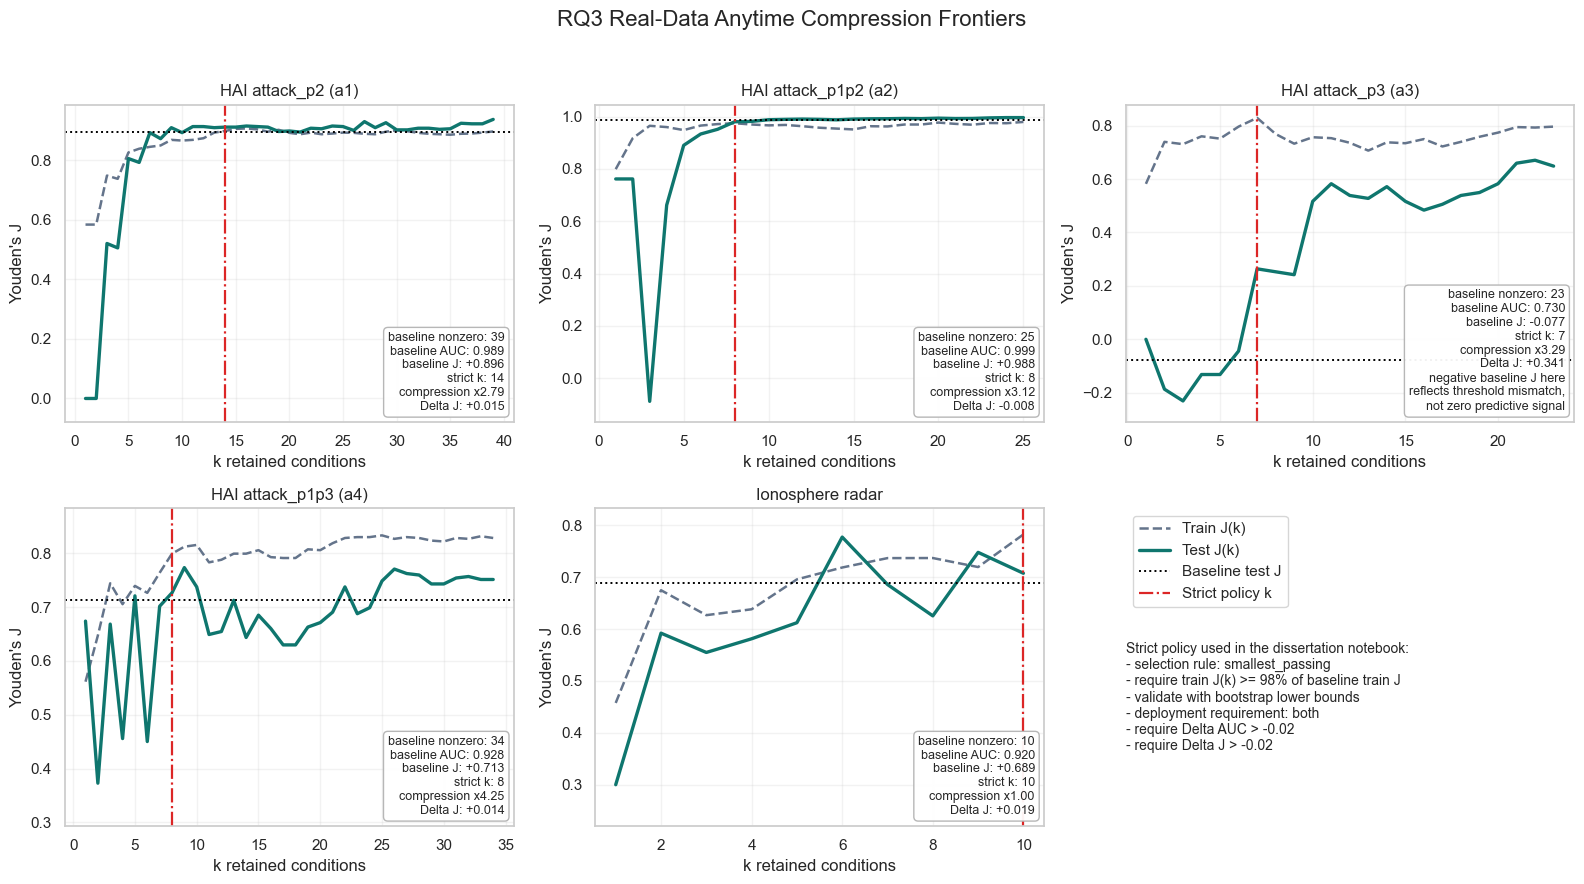

Saved: C:\Users\jason\ODU\dissertation\Figures\rq3_real_data_frontiers.png


In [57]:
strict_policy_df = policy_df.loc[np.isclose(policy_df["eps"], STRICT_POLICY_EPS)].copy()
domain_order = [spec["domain"] for spec in REAL_DATA_SPECS]
strict_lookup = strict_policy_df.set_index("domain")

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False, sharey=False)
axes = axes.flatten()

line_handles = None
for ax, domain in zip(axes, domain_order):
    sub = frontier_df.loc[frontier_df["domain"] == domain].copy()
    strict_row = strict_lookup.loc[domain]

    train_line = ax.plot(
        sub["k"],
        sub["train_j"],
        color="#64748b",
        linestyle="--",
        linewidth=1.8,
        label="Train J(k)",
    )[0]
    test_line = ax.plot(
        sub["k"],
        sub["test_j"],
        color="#0f766e",
        linewidth=2.4,
        label="Test J(k)",
    )[0]
    base_line = ax.axhline(
        strict_row["baseline_j_test"],
        color="black",
        linestyle=":",
        linewidth=1.4,
        label="Baseline test J",
    )
    chosen_line = ax.axvline(
        strict_row["k_selected"],
        color="#dc2626",
        linestyle="-.",
        linewidth=1.6,
        label="Strict policy k",
    )

    ax.set_title(domain)
    ax.set_xlabel("k retained conditions")
    ax.set_ylabel("Youden's J")
    ax.set_ylim(min(sub["test_j"].min(), strict_row["baseline_j_test"]) - 0.08, max(sub["train_j"].max(), sub["test_j"].max()) + 0.05)
    ax.grid(True, alpha=0.25)
    note_lines = [
        f"baseline nonzero: {int(strict_row['baseline_nonzero'])}",
        f"baseline AUC: {strict_row['baseline_auc_test']:.3f}",
        f"baseline J: {strict_row['baseline_j_test']:+.3f}",
        f"strict k: {int(strict_row['k_selected'])}",
        f"compression x{strict_row['compression_ratio']:.2f}",
        f"Delta J: {strict_row['delta_j']:+.3f}",
    ]
    if strict_row["baseline_j_test"] < 0:
        note_lines.extend(
            [
                "negative baseline J here",
                "reflects threshold mismatch,",
                "not zero predictive signal",
            ]
        )
    note = "\n".join(note_lines)
    ax.text(
        0.98,
        0.03,
        note,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.7", alpha=0.95),
    )
    line_handles = [train_line, test_line, base_line, chosen_line]

legend_ax = axes[-1]
legend_ax.axis("off")
legend_ax.legend(
    line_handles,
    ["Train J(k)", "Test J(k)", "Baseline test J", "Strict policy k"],
    loc="upper left",
    frameon=True,
)
legend_ax.text(
    0.0,
    0.58,
    "\n".join(
        [
            "Strict policy used in the dissertation notebook:",
            f"- selection rule: {STRICT_POLICY_K_SELECTION_RULE}",
            f"- require train J(k) >= {(1.0 - STRICT_POLICY_EPS):.0%} of baseline train J",
            "- validate with bootstrap lower bounds",
            f"- deployment requirement: {STRICT_POLICY_DEPLOYMENT_REQUIREMENT}",
            f"- require Delta AUC > -{STRICT_POLICY_AUC_MARGIN:.2f}",
            f"- require Delta J > -{STRICT_POLICY_J_MARGIN:.2f}",
        ]
    ),
    fontsize=10,
    va="top",
)

fig.suptitle("RQ3 Real-Data Anytime Compression Frontiers", fontsize=16, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

figure_path = MANUSCRIPT_FIGURES_DIR / "rq3_real_data_frontiers.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show(block=False)
print("Saved:", figure_path)


In [58]:
policy_display = policy_df.copy()
policy_display["policy"] = policy_display["eps"].map(
    lambda eps: STRICT_POLICY_LABEL if np.isclose(eps, STRICT_POLICY_EPS) else f"{int(round(100 * eps))}%"
)
policy_display["summary"] = policy_display.apply(
    lambda row: (
        f"k={int(row['k_selected'])}, "
        f"x{row['compression_ratio']:.2f}, "
        f"Delta J={row['delta_j']:+.3f}, "
        f"Delta AUC={row['delta_auc']:+.3f}"
    ),
    axis=1,
)
policy_pivot = policy_display.pivot(index="domain", columns="policy", values="summary")

render_markdown("### Policy Summary Across Compression Tolerances")
if display is not None:
    display(policy_pivot)
else:
    print(policy_pivot.to_string())


### Policy Summary Across Compression Tolerances

policy,1%,2%,5%
domain,,,
HAI attack_p1p2 (a2),"k=25, x1.00, Delta J=+0.008, Delta AUC=+0.001","k=8, x3.12, Delta J=-0.008, Delta AUC=-0.001","k=3, x8.33, Delta J=-1.076, Delta AUC=-0.234"
HAI attack_p1p3 (a4),"k=9, x3.78, Delta J=+0.061, Delta AUC=+0.019","k=8, x4.25, Delta J=+0.014, Delta AUC=+0.011","k=8, x4.25, Delta J=+0.014, Delta AUC=+0.011"
HAI attack_p2 (a1),"k=15, x2.60, Delta J=+0.015, Delta AUC=-0.010","k=14, x2.79, Delta J=+0.015, Delta AUC=-0.011","k=9, x4.33, Delta J=+0.013, Delta AUC=-0.018"
HAI attack_p3 (a3),"k=7, x3.29, Delta J=+0.341, Delta AUC=-0.003","k=7, x3.29, Delta J=+0.341, Delta AUC=-0.003","k=7, x3.29, Delta J=+0.341, Delta AUC=-0.003"
Ionosphere radar,"k=10, x1.00, Delta J=+0.019, Delta AUC=+0.010","k=10, x1.00, Delta J=+0.019, Delta AUC=+0.010","k=7, x1.43, Delta J=-0.003, Delta AUC=-0.009"


In [59]:
equivalence_display = equivalence_df.copy()
equivalence_display["AUC 95% CI"] = equivalence_display.apply(
    lambda row: f"[{row['auc_ci_low']:+.3f}, {row['auc_ci_high']:+.3f}]",
    axis=1,
)
equivalence_display["J 95% CI"] = equivalence_display.apply(
    lambda row: f"[{row['j_ci_low']:+.3f}, {row['j_ci_high']:+.3f}]",
    axis=1,
)
equivalence_display["AUC NI"] = equivalence_display["auc_noninferior"].map({True: "pass", False: "fail"})
equivalence_display["J NI"] = equivalence_display["j_noninferior"].map({True: "pass", False: "fail"})
equivalence_display["Deploy"] = equivalence_display["deployment_recommendation"].map({True: "yes", False: "no"})

columns = [
    "domain",
    "baseline_nonzero",
    "k_selected",
    "compression_ratio",
    "delta_auc",
    "AUC 95% CI",
    "AUC NI",
    "delta_j",
    "J 95% CI",
    "J NI",
    "deployment_requirement",
    "Deploy",
]
equivalence_pretty = equivalence_display[columns].copy()
equivalence_pretty = equivalence_pretty.rename(
    columns={
        "baseline_nonzero": "Baseline nz",
        "k_selected": "Strict k",
        "compression_ratio": "Compression x",
        "delta_auc": "Delta AUC",
        "delta_j": "Delta J",
        "deployment_requirement": "Deploy rule",
    }
)

render_markdown(f"### Strict {STRICT_POLICY_LABEL} Policy: Held-Out Non-Inferiority Summary")
if display is not None:
    display(equivalence_pretty)
else:
    print(equivalence_pretty.to_string(index=False))


### Strict 2% Policy: Held-Out Non-Inferiority Summary

,domain,Baseline nz,Strict k,Compression x,Delta AUC,AUC 95% CI,AUC NI,Delta J,J 95% CI,J NI,Deploy rule,Deploy
0,HAI attack_p2 (a1),39,14,2.785714,-0.011243,"[-0.016, -0.006]",pass,0.014815,"[-0.005, +0.036]",pass,both,yes
1,HAI attack_p1p2 (a2),25,8,3.125000,-0.001498,"[-0.002, -0.001]",pass,-0.007804,"[-0.012, -0.004]",pass,both,yes
2,HAI attack_p3 (a3),23,7,3.285714,-0.002959,"[-0.054, +0.050]",fail,0.340659,"[+0.223, +0.457]",pass,both,no
3,HAI attack_p1p3 (a4),34,8,4.250000,0.010825,"[+0.002, +0.023]",pass,0.013812,"[-0.026, +0.055]",fail,both,no
4,Ionosphere radar,10,10,1.000000,0.009868,"[-0.014, +0.038]",pass,0.018576,"[-0.123, +0.163]",fail,both,no


In [60]:
strict_policy_df = policy_df.loc[np.isclose(policy_df["eps"], STRICT_POLICY_EPS)].copy()
looser_eps = sorted(float(eps) for eps in POLICY_GRID if float(eps) > float(STRICT_POLICY_EPS))
comparison_eps = looser_eps[0] if looser_eps else None
comparison_policy_df = (
    policy_df.loc[np.isclose(policy_df["eps"], comparison_eps)].copy()
    if comparison_eps is not None
    else pd.DataFrame()
)

strong_compression = strict_policy_df.loc[strict_policy_df["compression_ratio"] > 2.0, ["domain", "baseline_nonzero", "k_selected", "compression_ratio"]]
accepted_domains = equivalence_df.loc[equivalence_df["deployment_recommendation"], "domain"].tolist()
rejected_domains = equivalence_df.loc[~equivalence_df["deployment_recommendation"], "domain"].tolist()

comparison_regressions = []
if comparison_eps is not None:
    for domain in strict_policy_df["domain"]:
        strict_row = strict_policy_df.loc[strict_policy_df["domain"] == domain].iloc[0]
        comparison_row = comparison_policy_df.loc[comparison_policy_df["domain"] == domain].iloc[0]
        if comparison_row["delta_j"] < strict_row["delta_j"] - STRICT_POLICY_J_MARGIN:
            comparison_regressions.append(domain)

lines = []
if len(strong_compression):
    compressed = ", ".join(
        f"{row.domain} ({int(row.baseline_nonzero)} -> {int(row.k_selected)}, x{row.compression_ratio:.2f})"
        for row in strong_compression.itertuples()
    )
    lines.append(
        f"- Under the strict {STRICT_POLICY_LABEL} policy, meaningful compression still occurs on {compressed}."
    )
if accepted_domains:
    lines.append(
        "- The configured held-out gate is fully satisfied on "
        + ", ".join(accepted_domains)
        + "."
    )
if rejected_domains:
    lines.append(
        "- The configured held-out gate remains mixed on "
        + ", ".join(rejected_domains)
        + ", which is useful because D004 is supposed to document when compression should **not** be adopted automatically."
    )
if comparison_regressions and comparison_eps is not None:
    lines.append(
        f"- Moving from the strict {STRICT_POLICY_LABEL} rule to the next looser {int(round(100 * comparison_eps))}% rule already causes visible degradation on "
        + ", ".join(comparison_regressions)
        + ", which is why the notebook keeps the full policy grid as cautionary reference points rather than as the default manuscript policy."
    )
lines.append(
    "- The ionosphere generic probe is especially informative: under the configured strict policy it refuses practical compression, which is directionally consistent with the D002 observation that this domain is protocol-sensitive and not a clean threshold-mediated win."
)

render_markdown("### D004 Takeaways\n" + "\n".join(lines))


### D004 Takeaways
- Under the strict 2% policy, meaningful compression still occurs on HAI attack_p2 (a1) (39 -> 14, x2.79), HAI attack_p1p2 (a2) (25 -> 8, x3.12), HAI attack_p3 (a3) (23 -> 7, x3.29), HAI attack_p1p3 (a4) (34 -> 8, x4.25).
- The configured held-out gate is fully satisfied on HAI attack_p2 (a1), HAI attack_p1p2 (a2).
- The configured held-out gate remains mixed on HAI attack_p3 (a3), HAI attack_p1p3 (a4), Ionosphere radar, which is useful because D004 is supposed to document when compression should **not** be adopted automatically.
- Moving from the strict 2% rule to the next looser 5% rule already causes visible degradation on HAI attack_p1p2 (a2), Ionosphere radar, which is why the notebook keeps the full policy grid as cautionary reference points rather than as the default manuscript policy.
- The ionosphere generic probe is especially informative: under the configured strict policy it refuses practical compression, which is directionally consistent with the D002 observation that this domain is protocol-sensitive and not a clean threshold-mediated win.